# PD Model Training – PyTorch ANN (02b)

**Purpose:** Train a PyTorch ANN on the **same** origination-only features and out-of-time split as 02a, with the same rigour (early stopping, LayerNorm, Dropout, class weight). Compare in-sample vs out-of-time AUC gap vs XGBoost/LightGBM stack. Conclusion: **tree ensembles generalise better than ANN** on tabular credit data without temporal leakage.

**Prerequisites:** Run **01** and **02a** first (parquet + 02a model artifact for comparison).

## 1. Load same data as 02a (same split, same features)

In [1]:
import sys
import os
import time
import random
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent
if not (ROOT / "credit_risk").is_dir():
    raise RuntimeError("Repo root not found. Run from ocr-agentic-rag or notebooks/.")
_root_str = str(ROOT)
# Ensure repo root is the only source for credit_risk (avoid KeyError from stale/cached imports)
for _k in list(sys.modules.keys()):
    if _k == "credit_risk" or _k.startswith("credit_risk."):
        del sys.modules[_k]
if _root_str in sys.path:
    sys.path.remove(_root_str)
sys.path.insert(0, _root_str)
os.chdir(_root_str)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage_v2
from credit_risk.feature_engineering.feature_screening import screen_features_train_only
from sklearn.model_selection import train_test_split

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01 first to create lendingclub_engineered.parquet")

df = pd.read_parquet(DATA_PATH)
all_feature_names = get_feature_names_no_leakage_v2()
X = df[[c for c in all_feature_names if c in df.columns]].copy()
y = df["default"]
for c in all_feature_names:
    if c not in X.columns:
        X[c] = 0.0
X = X[all_feature_names]

if "split" in df.columns and (df["split"] == "val").sum() >= 1 and (df["split"] == "test").sum() >= 1:
    train_idx = df["split"] == "train"
    val_idx = df["split"] == "val"
    test_idx = df["split"] == "test"
    X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
    y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
    print(f"Out-of-time split: Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")
else:
    X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest)
    print(f"Random split: Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")

screening = screen_features_train_only(X_train, y_train, missingness_threshold=0.50, min_ks=0.001, corr_threshold=0.95)
feature_names = screening.selected_features
X_train = X_train[feature_names]
X_val = X_val[feature_names]
X_test = X_test[feature_names]
medians = X_train.median()
X_train_filled = X_train.fillna(medians)
X_val_filled = X_val.fillna(medians)
X_test_filled = X_test.fillna(medians)
print(f"Selected {len(feature_names)} features (same as 02a)")

Out-of-time split: Train 6,529 / Val 11,536 / Test 21,721
Selected 77 features (same as 02a)


## 2. Train ANN (early stopping, LayerNorm, Dropout, class weight)

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

scaler_ann = StandardScaler()
X_train_ann = scaler_ann.fit_transform(X_train_filled)
X_val_ann = scaler_ann.transform(X_val_filled)
X_test_ann = scaler_ann.transform(X_test_filled)

from credit_risk.models.pd_ann import PDAnnClassifier

# Same class weight as 02a (n_neg/n_pos on train) for apples-to-apples
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

# Stratified 5-fold CV for in-sample val AUC (mean ± std)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ann_cv_aucs = []
for tr_idx, va_idx in skf.split(X_train_ann, y_train):
    X_f, X_va = X_train_ann[tr_idx], X_train_ann[va_idx]
    y_f, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    ann_fold = PDAnnClassifier(epochs=20, batch_size=32, early_stopping_patience=3, random_state=42, scale_pos_weight=scale_pos_weight)
    ann_fold.fit(X_f, y_f.values, X_val=X_va, y_val=y_va.values)
    p_va = ann_fold.predict_proba(X_va)[:, 1]
    ann_cv_aucs.append(roc_auc_score(y_va, p_va))
ann_cv_mean = np.mean(ann_cv_aucs)
ann_cv_std = np.std(ann_cv_aucs)
print(f"ANN 5-fold CV val AUC: {ann_cv_mean:.4f} ± {ann_cv_std:.4f}")

# Final fit on full train with early stopping on val
ann_train_start = time.perf_counter()
ann_model = PDAnnClassifier(epochs=20, batch_size=32, early_stopping_patience=3, random_state=42, scale_pos_weight=scale_pos_weight)
ann_model.fit(X_train_ann, y_train.values, X_val=X_val_ann, y_val=y_val.values)
ann_training_sec = time.perf_counter() - ann_train_start
p_val_ann = ann_model.predict_proba(X_val_ann)[:, 1]
ann_val_auc = roc_auc_score(y_val, p_val_ann)
ann_train_auc = roc_auc_score(y_train, ann_model.predict_proba(X_train_ann)[:, 1])
print(f"ANN train AUC: {ann_train_auc:.4f} | val AUC: {ann_val_auc:.4f} | training time: {ann_training_sec:.1f}s")

# Optimal threshold (max F1) on val — same as 02a Section 4 for apples-to-apples
from sklearn.metrics import f1_score
best_f1_val, best_threshold_ann = 0.0, 0.5
for t in np.linspace(0.2, 0.8, 31):
    f1 = f1_score(y_val, (p_val_ann >= t).astype(int), zero_division=0)
    if f1 > best_f1_val:
        best_f1_val, best_threshold_ann = f1, t
print("Optimal threshold (max F1 on val):", round(best_threshold_ann, 3), "-> val F1", round(best_f1_val, 4))

ANN 5-fold CV val AUC: 0.6382 ± 0.0189
ANN train AUC: 0.8103 | val AUC: 0.6072 | training time: 15.3s
Optimal threshold (max F1 on val): 0.42 -> val F1 0.2607


## 3. Learning curves (train vs val AUC per epoch)

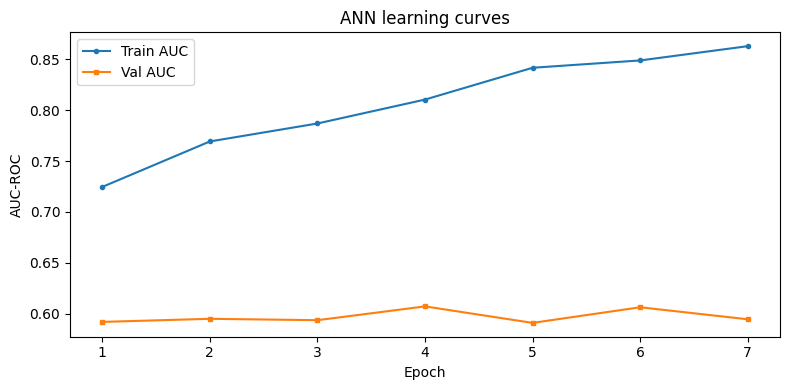

In [3]:
import matplotlib.pyplot as plt

if hasattr(ann_model, "history_") and ann_model.history_:
    h = ann_model.history_
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(h["train_auc"]) + 1), h["train_auc"], label="Train AUC", marker="o", markersize=3)
    plt.plot(range(1, len(h["val_auc"]) + 1), h["val_auc"], label="Val AUC", marker="s", markersize=3)
    plt.xlabel("Epoch")
    plt.ylabel("AUC-ROC")
    plt.legend()
    plt.title("ANN learning curves")
    plt.tight_layout()
    plt.show()

## 4. Out-of-time test & in-sample vs out-of-time gap (ANN only; used in 02z)


In [4]:
from sklearn.metrics import roc_curve, f1_score

p_test_ann = ann_model.predict_proba(X_test_ann)[:, 1]
ann_test_auc = roc_auc_score(y_test, p_test_ann)
fpr_a, tpr_a, _ = roc_curve(y_test, p_test_ann)
ann_test_ks = np.max(np.abs(tpr_a - fpr_a))
# Test F1 at optimal threshold (same metric as 02a)
ann_test_f1 = f1_score(y_test, (p_test_ann >= best_threshold_ann).astype(int), zero_division=0) if "best_threshold_ann" in dir() else None
print(f"ANN out-of-time: test AUC = {ann_test_auc:.4f}, KS = {ann_test_ks:.4f}" + (f", test F1 @ t={best_threshold_ann:.2f} = {ann_test_f1:.4f}" if ann_test_f1 is not None else ""))

# In-sample (val) vs out-of-time (test) AUC gap for ANN only
ann_gap = ann_val_auc - ann_test_auc
print("\nIn-sample (val) vs out-of-time (test) AUC gap (ANN only):")
print(f"  val AUC = {ann_val_auc:.4f}, test AUC = {ann_test_auc:.4f}, gap = {ann_gap:.4f}")
# Cross-model gap comparisons (XGBoost stack vs ANN) are handled in 02z_pd_model_comparison.ipynb.

ANN out-of-time: test AUC = 0.6163, KS = 0.1778, test F1 @ t=0.42 = 0.2977

In-sample (val) vs out-of-time (test) AUC gap (ANN only):
  val AUC = 0.6072, test AUC = 0.6163, gap = -0.0091


## 5. Notes

This notebook trains and evaluates the **ANN PD model** and saves its artifact for downstream comparison. Cross-model conclusions (ANN vs XGBoost/LightGBM stack vs Logistic Regression vs quantum) are documented in `02z_pd_model_comparison.ipynb`.

## 6. Save ANN artifact and training time for 02z

In [5]:
import joblib
import json

MODEL_DIR = ROOT / "models" / "pd"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ann_artifact = {
    "model": ann_model,
    "scaler": scaler_ann,
    "feature_names": feature_names,
    "ann_val_auc": ann_val_auc,
    "ann_test_auc": ann_test_auc,
    "ann_train_auc": ann_train_auc,
    "training_time_sec": ann_training_sec,
}
joblib.dump(ann_artifact, MODEL_DIR / "pd_model_ann_v2.pkl")
print("Saved ANN to", MODEL_DIR / "pd_model_ann_v2.pkl")

training_meta = {}
if (MODEL_DIR / "training_meta.json").exists():
    with open(MODEL_DIR / "training_meta.json", encoding="utf-8") as f:
        training_meta = json.load(f)
training_meta["ann_training_sec"] = ann_training_sec
with open(MODEL_DIR / "training_meta.json", "w", encoding="utf-8") as f:
    json.dump(training_meta, f, indent=2)
print("Updated training_meta.json for 02z")

Saved ANN to c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\models\pd\pd_model_ann_v2.pkl
Updated training_meta.json for 02z
